### Dataset: https://www.kaggle.com/datasets/saisirishan/indian-vehicle-dataset/data

In [1]:
import os

%pwd

'c:\\Users\\Hp\\Documents\\GitHub\\traffic_scene\\notebooks'

In [2]:
os.chdir("../")

%pwd

'c:\\Users\\Hp\\Documents\\GitHub\\traffic_scene'

In [3]:
import cv2, random
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt


# configs
BASE_DIR = Path("dataset/anpr")
DATASET_DIR = (BASE_DIR / "cleaned")
YOLO_DIR = (BASE_DIR / "processed")
YOLO_ANNOTATION_EXT = ".txt"

DATA_YAML = (YOLO_DIR / "data.yaml")
MODEL_ARCH = "models/yolov8n.pt"

RUN_NAME = "anpr_v1"
EPOCHS_DRY = 1
EPOCHS_FULL = 50
IMG_SIZE = 640
SAMPLES_TO_VISUALIZE = 5  

In [10]:
# STEP 1: SANITY CHECK (VISUALIZE ANNOTATIONS)
def visualize_samples(data_yaml, pro_dir, yolo_annotation_ext, samples):
    
    dataset_path = pro_dir / "images" / "train"
    label_path = pro_dir / "labels" / "train"
    all_images = list(dataset_path.glob("*.jpg")) + list(dataset_path.glob("*.jpeg")) + list(dataset_path.glob("*.png"))
    
    random.shuffle(all_images)

    print(f"[INFO] Visualizing {samples} random samples with bounding boxes...")
    for img_file in all_images[:samples]:
        label_file = label_path / (img_file.stem + yolo_annotation_ext)
        img = cv2.imread(str(img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if label_file.exists():
            h, w, _ = img.shape
            with open(label_file, "r") as f:
                lines = f.readlines()
                for line in lines:
                    cls, x, y, bw, bh = map(float, line.strip().split())
                    x, y, bw, bh = x * w, y * h, bw * w, bh * h
                    x1, y1 = int(x - bw/2), int(y - bh/2)
                    x2, y2 = int(x + bw/2), int(y + bh/2)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, "license_plate", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        plt.imshow(img)
        plt.axis("off")
        plt.show()

# STEP 2: DRY RUN TRAINING
def dry_run_training(data_yaml, model_arch, epochs, imgsz, run_name):
    print(f"[INFO] Starting Dry Run (epochs={epochs})...")
    model = YOLO(model_arch)
    model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        project="runs/detect",
        name=run_name + "_dry",
        verbose=True,
        plots=True,
    )
    print("[INFO] Dry Run Completed. Check runs/detect folder.")

# STEP 3: FULL TRAINING
def full_training(data_yaml, model_arch, epochs, imgsz, run_name):
    print(f"[INFO] Starting Full Training (epochs={epochs})...")
    model = YOLO(model_arch)
    model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        project="runs/detect",
        name=run_name,
        verbose=True,
        plots=True,
    )
    print("[INFO] Full Training Completed. Check runs/detect folder.")

[INFO] Visualizing 5 random samples with bounding boxes...


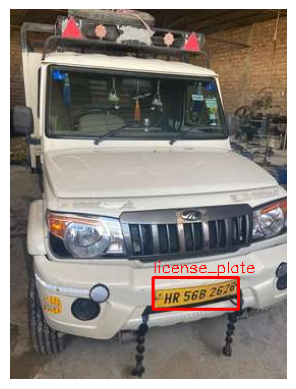

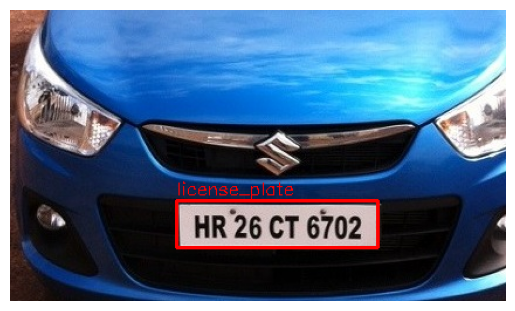

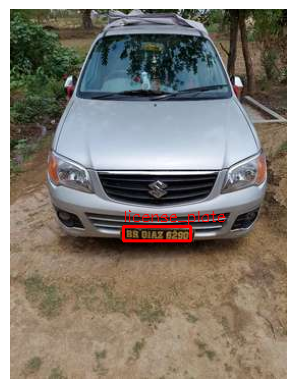

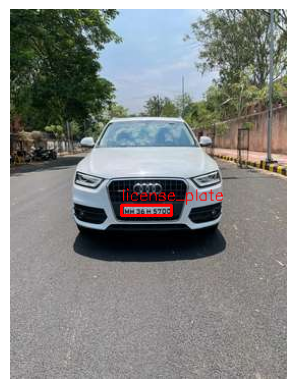

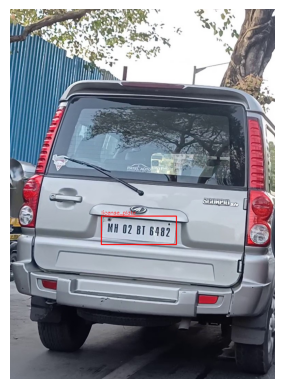

In [11]:
# STEP 1: Visualize Sample Images
visualize_samples(DATA_YAML, YOLO_DIR, YOLO_ANNOTATION_EXT, SAMPLES_TO_VISUALIZE)

In [ ]:
# STEP 2: Dry Run
dry_run_training(DATA_YAML, MODEL_ARCH, EPOCHS_DRY, IMG_SIZE, RUN_NAME)

In [ ]:
# STEP 3: Full Training
full_training(DATA_YAML, MODEL_ARCH, EPOCHS_FULL, IMG_SIZE, RUN_NAME)